In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\prach\.cache\kagglehub\datasets\vipoooool\new-plant-diseases-dataset\versions\2


In [4]:
import kagglehub
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Keras Layers & Model
from tensorflow.keras import layers, Model

# Image augmentation + loading
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Callbacks for training optimization
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

# MobileNet preprocess
from tensorflow.keras.applications.mobilenet import preprocess_input

# Evaluation libraries
from sklearn.metrics import classification_report, confusion_matrix

# Optional: only for visualization
import seaborn as sns

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.0


In [5]:
# ---------------- USER CONFIG ----------------
# Update these paths if your dataset is elsewhere
TRAIN_DIR = r'/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
VALID_DIR = r'/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'
TEST_DIR  = r'/kaggle/input/new-plant-diseases-dataset/test/test'  # optional; can point to VALID_DIR if no test folder

In [6]:
# This matches the usual structure of the dataset
BASE_DIR = os.path.join(
    path,
    "New Plant Diseases Dataset(Augmented)",
    "New Plant Diseases Dataset(Augmented)"
)

print("TRAIN_DIR:", TRAIN_DIR)
print("VALID_DIR:", VALID_DIR)
print("TEST_DIR :", TEST_DIR)

TRAIN_DIR: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
VALID_DIR: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
TEST_DIR : /kaggle/input/new-plant-diseases-dataset/test/test


In [7]:
# =========================================
# 3. QUICK DATA CHECK & SAMPLE GRID
# =========================================
plt.figure(figsize=(18, 18))
count = 0
plant_names = []
total_images = 0

for cls in os.listdir(TRAIN_DIR):
    class_dir = os.path.join(TRAIN_DIR, cls)
    if not os.path.isdir(class_dir):
        continue

    plant_names.append(cls)
    images_path = os.listdir(class_dir)
    print("Number of images of", cls, ":", len(images_path))
    total_images += len(images_path)

    # Show only first 25 classes
    if count < 25 and len(images_path) > 0:
        count += 1
        plt.subplot(5, 5, count)
        img_path = os.path.join(class_dir, images_path[0])
        image_show = plt.imread(img_path)
        plt.imshow(image_show)
        plt.xlabel(cls, fontsize=8)
        plt.xticks([])
        plt.yticks([])

print("\nTotal number of images:", total_images)
print("Number of classes:", len(plant_names))
print("Class names:", plant_names)
plt.tight_layout()
plt.show()

FileNotFoundError: [WinError 3] The system cannot find the path specified: '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'

<Figure size 1800x1800 with 0 Axes>

In [ ]:
# =========================================
# 4. DATA GENERATORS
# =========================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode='nearest',
    width_shift_range=0.2,
    height_shift_range=0.2
    # no rescale; preprocess_input will handle normalization
)

val_datagen = ImageDataGenerator()

train = train_datagen.flow_from_directory(
    directory=TRAIN_DIR,
    batch_size=BATCH_SIZE,
    target_size=IMG_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=True,
    seed=42
)

valid = val_datagen.flow_from_directory(
    directory=VALID_DIR,
    batch_size=BATCH_SIZE,
    target_size=IMG_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False   # important for confusion matrix
)

num_classes = train.num_classes
print("Detected classes:", num_classes)
print("Class indices:", train.class_indices)



Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Detected classes: 38
Class indices: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26,

In [ ]:
# -------- SEQUENTIAL MODEL (FINAL FIXED VERSION) -------- #

from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input


base_model = MobileNet(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224, 3)
)
base_model.trainable = False   # freeze base layers

model = tf.keras.Sequential([
    layers.Input(shape=(224,224, 3)),

    # Preprocessing layer
    layers.Lambda(preprocess_input),

    # MobileNet base
    base_model,

    # Custom CNN layers
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 256)      │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 3, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,955,814 (22.72 MB)

 Trainable params: 2,726,182 (10.40 MB)

 Non-trainable params: 3,229,632 (12.32 MB)

In [ ]:
# =========================================
# 6. CALLBACKS & COMPILE
# =========================================
es = EarlyStopping(
    monitor='val_accuracy',
    verbose=1,
    patience=7,
    mode='auto',
    restore_best_weights=True
)

mc = ModelCheckpoint(
    filepath='/content/best_model.keras',
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True
)

lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    verbose=1,
    patience=5,
    min_lr=0.0001
)

model.compile(
    optimizer='Adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# =========================================
# 7. TRAINING (MOBILENET)
# =========================================

EPOCHS = 30
STEPS_PER_EPOCH = 200        # Optional override

history = model.fit(
    train,
    validation_data=valid,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    callbacks=[mc, es, lr],
    verbose=1
)

# Save final MobileNet model
model.save("MOBILENET_CROP_DISEASE.keras")
print("Model saved as MOBILENET_CROP_DISEASE.keras")


Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.3223 - loss: 2.5227
Epoch 1: val_accuracy improved from None to 0.76798, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 215s 982ms/step - accuracy: 0.4825 - loss: 1.8323 - val_accuracy: 0.7680 - val_loss: 0.7380 - learning_rate: 0.0010
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.7064 - loss: 0.9487
Epoch 2: val_accuracy improved from 0.76798 to 0.86820, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 133s 667ms/step - accuracy: 0.7311 - loss: 0.8775 - val_accuracy: 0.8682 - val_loss: 0.4114 - learning_rate: 0.0010
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.8001 - loss: 0.6602
Epoch 3: val_accuracy did not improve from 0.86820
200/200 ━━━━━━━━━━━━━━━━━━━━ 125s 629ms/step - accuracy: 0.8086 - loss: 0.6468 -

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 11: val_accuracy improved from 0.92824 to 0.92972, saving model to /content/best_model.keras

Epoch 11: finished saving model to /content/best_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 127s 640ms/step - accuracy: 0.8979 - loss: 0.3317 - val_accuracy: 0.9297 - val_loss: 0.2265 - learning_rate: 0.0010
Epoch 12/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.8998 - loss: 0.3181
Epoch 12: val_accuracy improved from 0.92972 to 0.93854, saving model to /content/best_model.keras

Epoch 12: finished saving model to /content/best_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 118s 589ms/step - accuracy: 0.8994 - loss: 0.3301 - val_accuracy: 0.9385 - val_loss: 0.2036 - learning_rate: 0.0010
Epoch 13/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.8981 - loss: 0.3484
Epoch 13: val_accuracy did not improve from 0.93854
200/200 ━━━━━━━━━━━━━━━━━━━━ 127s 637ms/step - accuracy: 0.9039 - loss: 0.3384 - val_accuracy: 0.9280 - val_loss: 0.2341 - learning_rate: 0.0010
Epoch 14/30


In [ ]:
# =========================================
# 8. CLASS NAMES (for reports & prediction)
# =========================================
idx2class = {v: k for k, v in train.class_indices.items()}
class_names = [idx2class[i] for i in range(len(idx2class))]

print("Number of classes:", len(class_names))
print("Sample class names:", class_names[:10])

Number of classes: 38
Sample class names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']


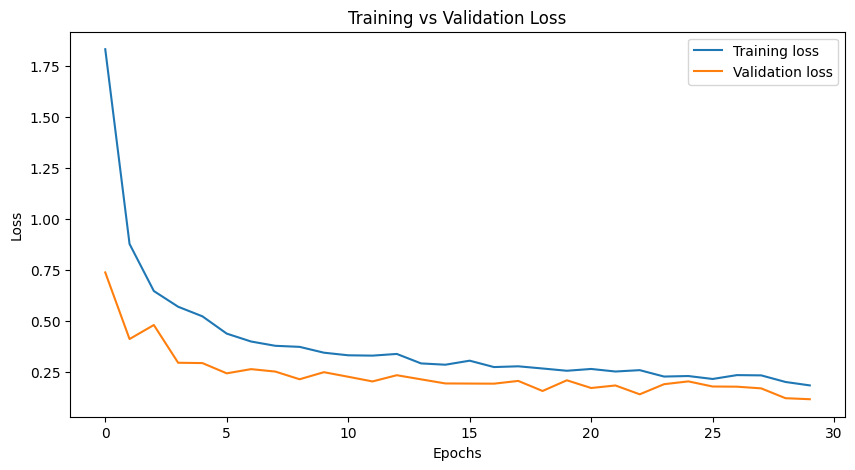

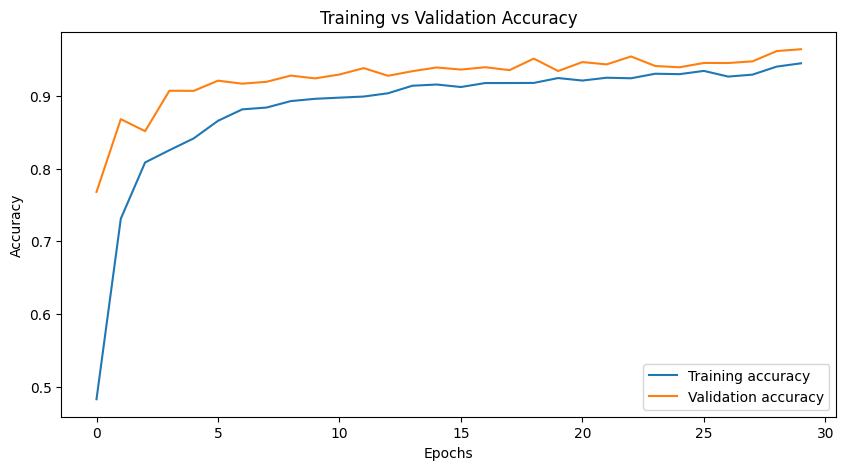

In [ ]:
# =========================================
# 9. TRAINING & VALIDATION CURVES
# =========================================
%matplotlib inline

# Loss graph
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Accuracy graph
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


In [ ]:
# =========================================
# 10. EVALUATE ON TRAIN & VALIDATION
# =========================================
train_loss, train_acc = model.evaluate(train, verbose=1)
print(f"Training Loss: {train_loss:.4f}")
print(f"Training Accuracy: {train_acc:.4f}")

val_loss, val_acc = model.evaluate(valid, verbose=1)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 885s 403ms/step - accuracy: 0.9685 - loss: 0.0972
Training Loss: 0.0972
Training Accuracy: 0.9685
550/550 ━━━━━━━━━━━━━━━━━━━━ 33s 61ms/step - accuracy: 0.9645 - loss: 0.1164
Validation Loss: 0.1164
Validation Accuracy: 0.9645


550/550 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step
y_true shape: (17572,)
y_pred shape: (17572,)

Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.95      0.97       504
                                 Apple___Black_rot       0.98      1.00      0.99       497
                          Apple___Cedar_apple_rust       0.98      1.00      0.99       440
                                   Apple___healthy       0.98      0.97      0.97       502
                               Blueberry___healthy       0.98      0.99      0.99       454
          Cherry_(including_sour)___Powdery_mildew       0.99      1.00      0.99       421
                 Cherry_(including_sour)___healthy       0.99      1.00      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.93      0.89      0.91       410
                       Corn_(maize)___Common_rust_       

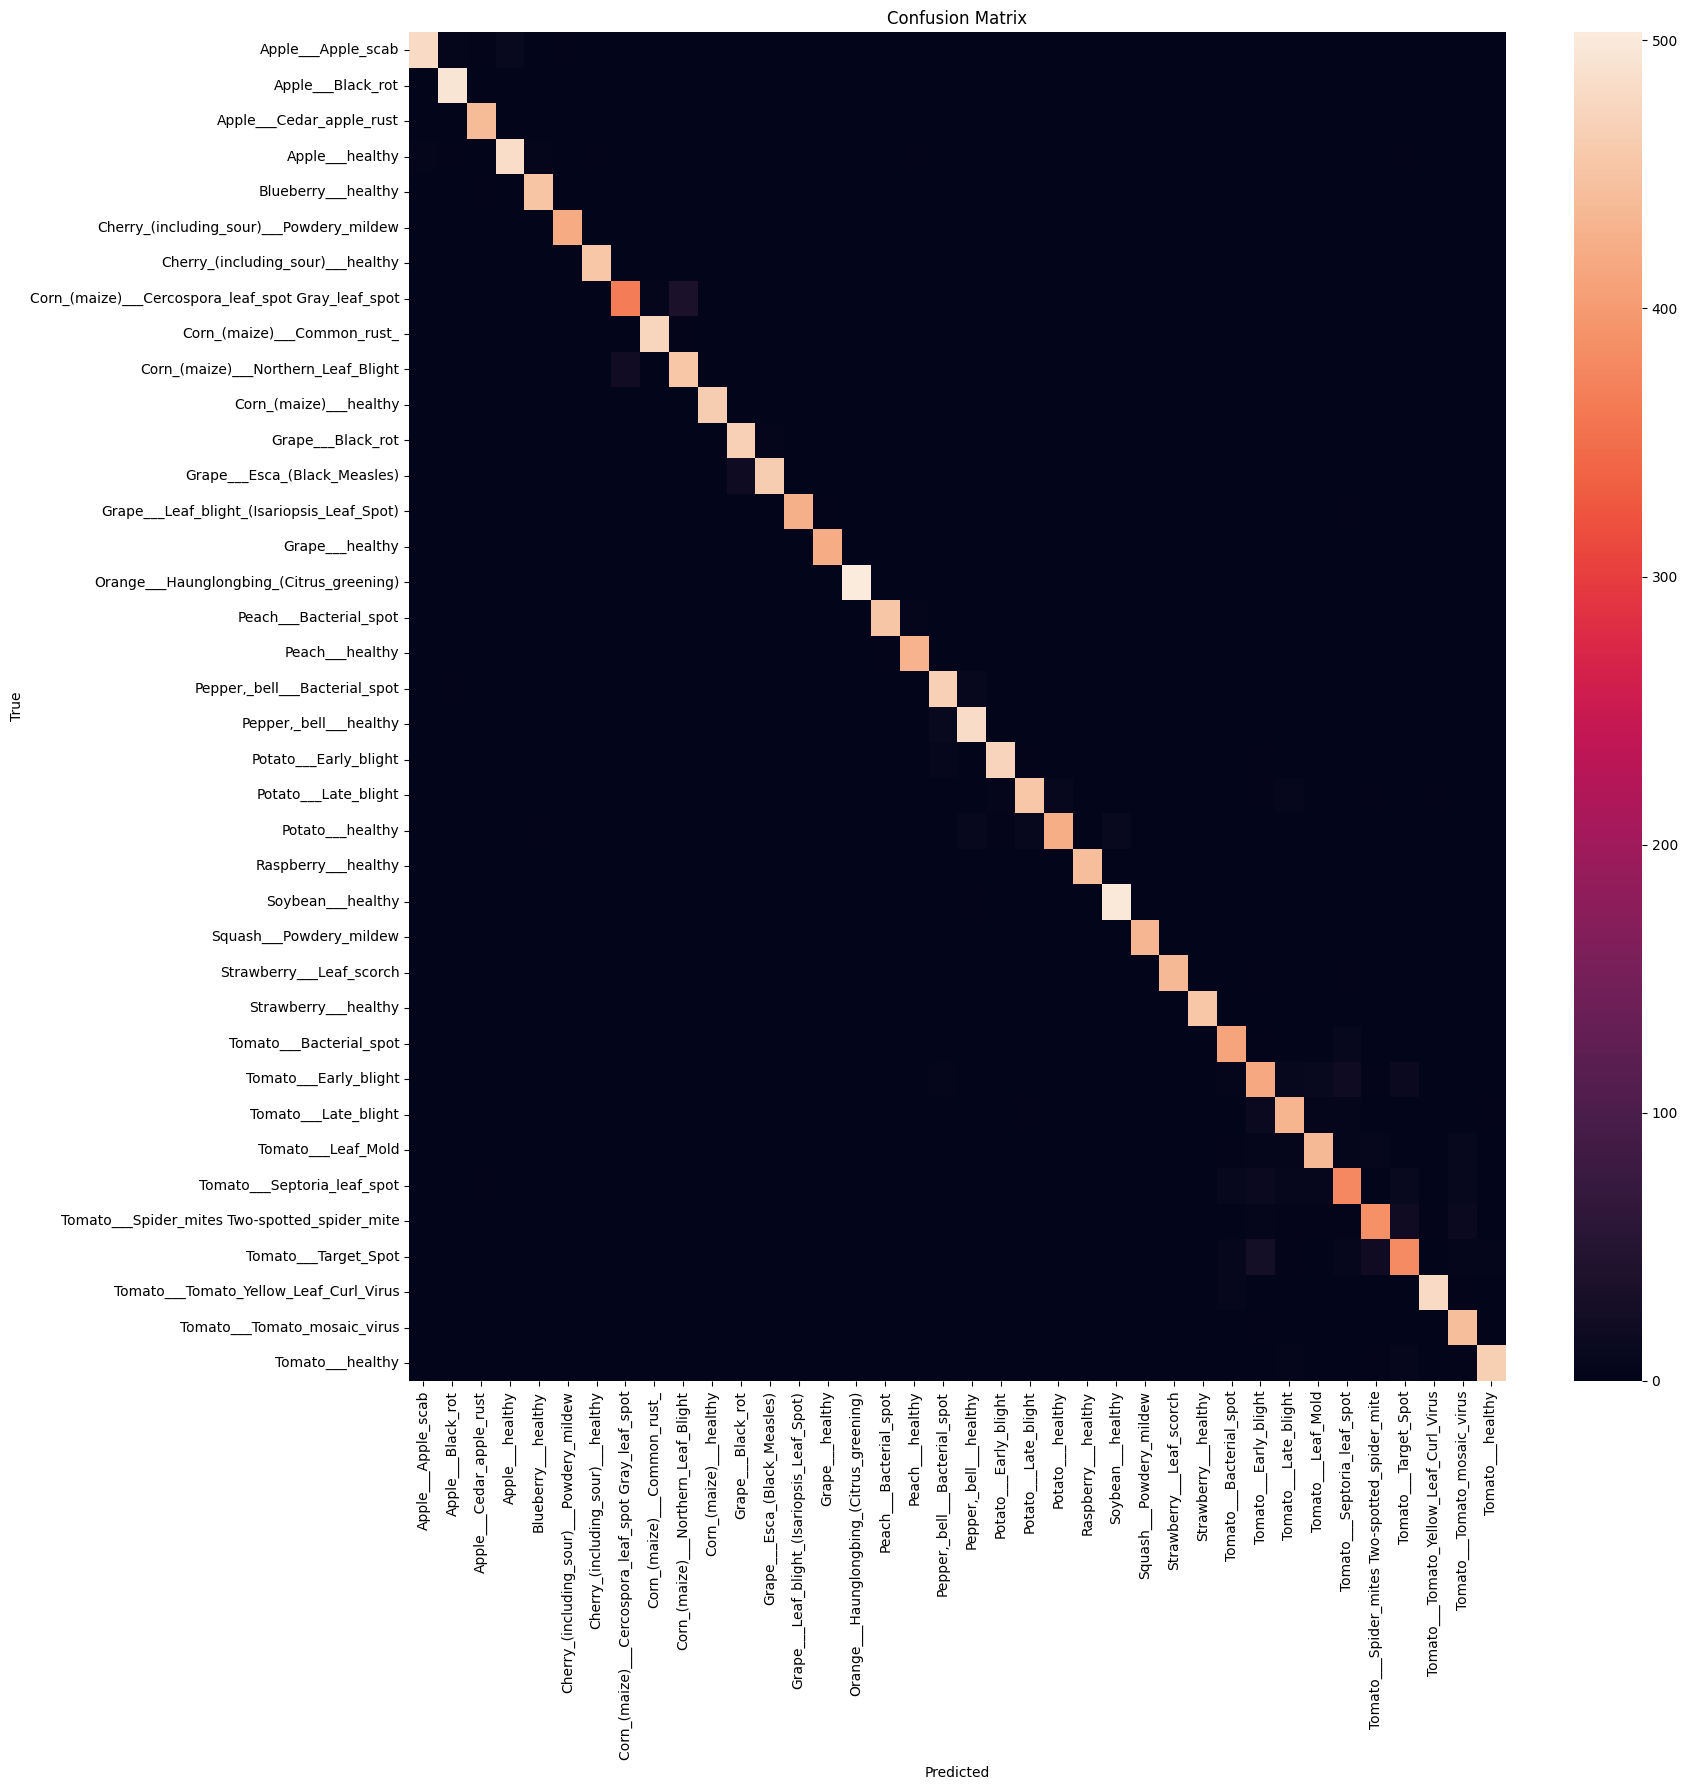

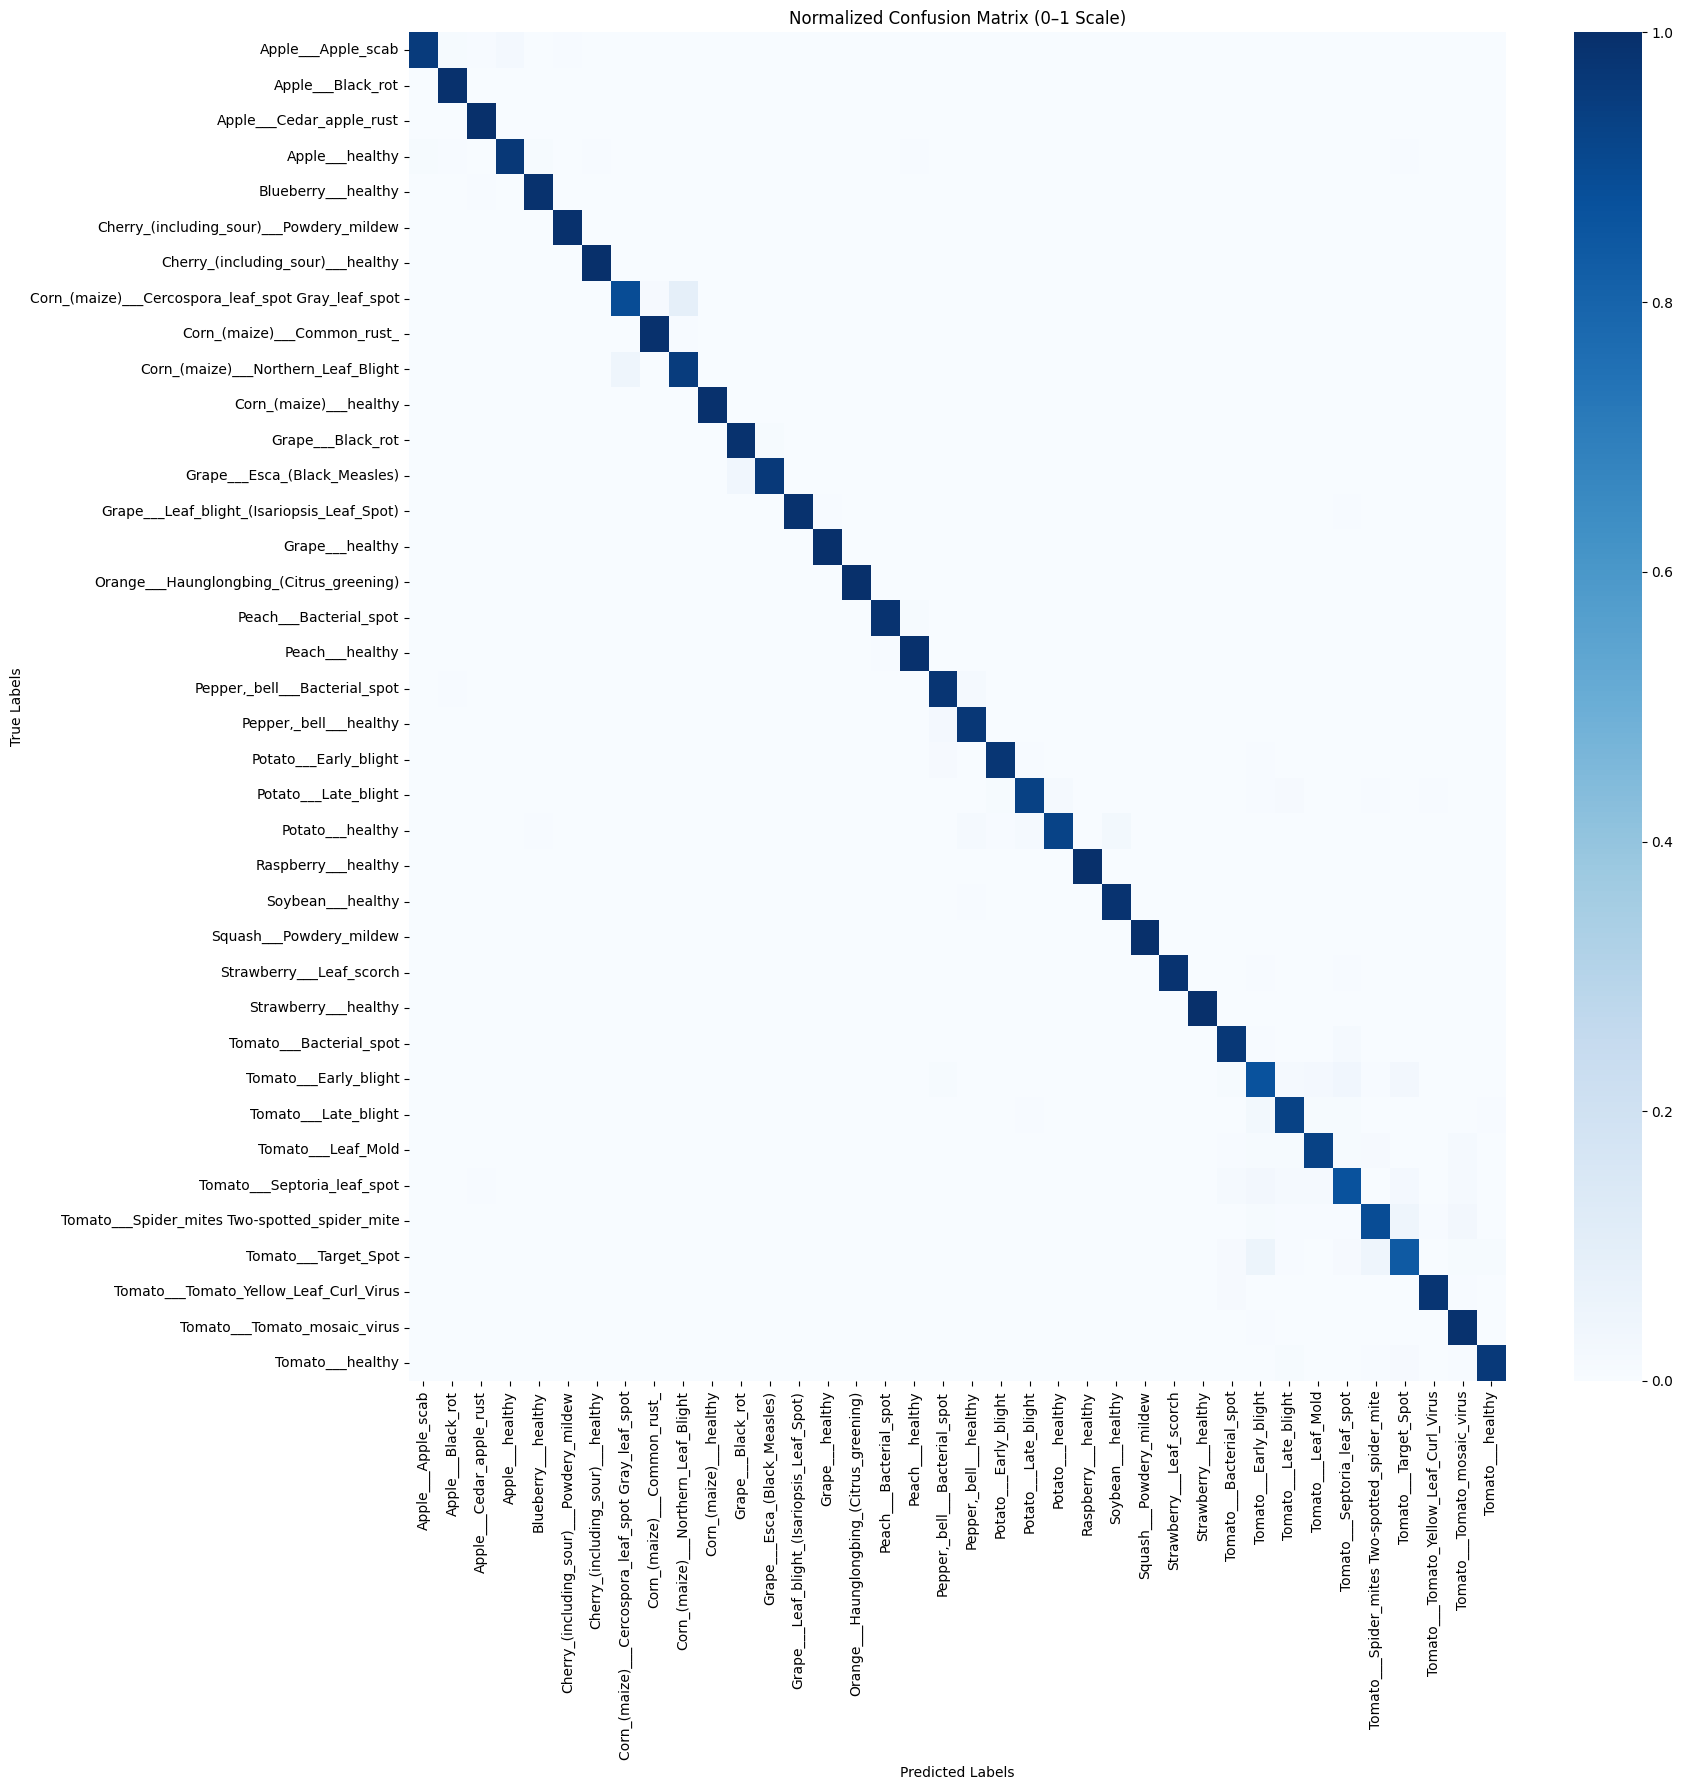

In [ ]:
# =========================================
# 11. CLASSIFICATION REPORT + CONFUSION MATRIX
# =========================================
# Reset validation generator
valid.reset()

# True labels
y_true = valid.classes

# Predictions
y_prob = model.predict(valid, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

# ----- Classification Report -----
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# ----- Raw Confusion Matrix -----
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 18))
sns.heatmap(
    cm,
    annot=False,           # change to True if you want counts visible
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ----- Normalized Confusion Matrix -----
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(18, 18))
sns.heatmap(
    cm_normalized,
    annot=False,           # True to see decimal values
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Normalized Confusion Matrix (0–1 Scale)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Saving OIP.jpg to OIP.jpg
Image selected: OIP.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step

Prediction Summary:
Crop        : Corn_(maize)
Condition   : healthy
Status      : HEALTHY ✅
Confidence  : 89.08%

Top 3 predictions:
Corn_(maize)___healthy  (Healthy) : 89.08%
Tomato___Late_blight  (Diseased) : 7.22%
Tomato___Early_blight  (Diseased) : 3.59%


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


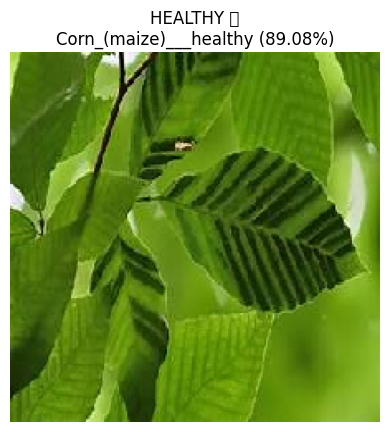

In [ ]:
# =========================================
# 12. PREDICTION ON UPLOADED IMAGE (with Healthy/Diseased check)
# =========================================
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

uploaded = files.upload()   # Choose an image from your system

for filename in uploaded.keys():
    img_path = filename
    print("Image selected:", img_path)

    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # (1, 224, 224, 3)

    # Predict
    preds = model.predict(img_array)
    pred_idx = np.argmax(preds[0])
    pred_class = class_names[pred_idx]
    confidence = preds[0][pred_idx]

    # --------- Healthy vs Diseased logic ----------
    if "healthy" in pred_class.lower():
        health_status = "HEALTHY ✅"
    else:
        health_status = "DISEASED ⚠️"

    # Optional: split crop and condition (if label like 'Apple___Black_rot')
    if "___" in pred_class:
        crop_name, condition = pred_class.split("___", 1)
    else:
        crop_name, condition = pred_class, "Unknown/Not formatted"

    print("\nPrediction Summary:")
    print(f"Crop        : {crop_name}")
    print(f"Condition   : {condition}")
    print(f"Status      : {health_status}")
    print(f"Confidence  : {confidence*100:.2f}%")

    # Top-3 predictions
    top_indices = preds[0].argsort()[-3:][::-1]
    print("\nTop 3 predictions:")
    for i in top_indices:
        label = class_names[i]
        if "___" in label:
            crop_i, cond_i = label.split("___", 1)
        else:
            crop_i, cond_i = label, "Unknown/Not formatted"

        status_i = "Healthy" if "healthy" in label.lower() else "Diseased"
        print(f"{label}  ({status_i}) : {preds[0][i]*100:.2f}%")

    # Show image with prediction
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{health_status}\n{pred_class} ({confidence*100:.2f}%)")
    plt.show()


Saving anthracnose-1.jpg to anthracnose-1.jpg
Image selected: anthracnose-1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

Prediction Summary:
Crop        : Tomato
Condition   : Early_blight
Status      : DISEASED ⚠️
Confidence  : 74.18%

Top 3 predictions:
Tomato___Early_blight  (Diseased) : 74.18%
Strawberry___Leaf_scorch  (Diseased) : 21.36%
Potato___Early_blight  (Diseased) : 2.31%


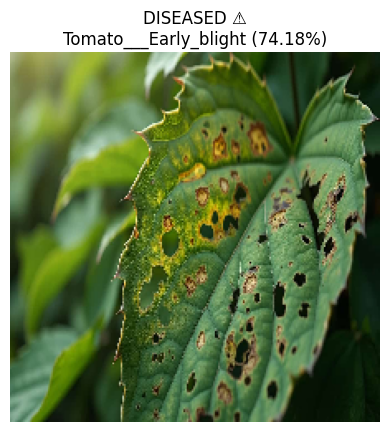

In [ ]:
# =========================================
# 12. PREDICTION ON UPLOADED IMAGE (with Healthy/Diseased check)
# =========================================
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

uploaded = files.upload()   # Choose an image from your system

for filename in uploaded.keys():
    img_path = filename
    print("Image selected:", img_path)

    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # (1, 224, 224, 3)

    # Predict
    preds = model.predict(img_array)
    pred_idx = np.argmax(preds[0])
    pred_class = class_names[pred_idx]
    confidence = preds[0][pred_idx]

    # --------- Healthy vs Diseased logic ----------
    if "healthy" in pred_class.lower():
        health_status = "HEALTHY ✅"
    else:
        health_status = "DISEASED ⚠️"

    # Optional: split crop and condition (if label like 'Apple___Black_rot')
    if "___" in pred_class:
        crop_name, condition = pred_class.split("___", 1)
    else:
        crop_name, condition = pred_class, "Unknown/Not formatted"

    print("\nPrediction Summary:")
    print(f"Crop        : {crop_name}")
    print(f"Condition   : {condition}")
    print(f"Status      : {health_status}")
    print(f"Confidence  : {confidence*100:.2f}%")

    # Top-3 predictions
    top_indices = preds[0].argsort()[-3:][::-1]
    print("\nTop 3 predictions:")
    for i in top_indices:
        label = class_names[i]
        if "___" in label:
            crop_i, cond_i = label.split("___", 1)
        else:
            crop_i, cond_i = label, "Unknown/Not formatted"

        status_i = "Healthy" if "healthy" in label.lower() else "Diseased"
        print(f"{label}  ({status_i}) : {preds[0][i]*100:.2f}%")

    # Show image with prediction
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{health_status}\n{pred_class} ({confidence*100:.2f}%)")
    plt.show()


In [ ]:
model.save("plant_disease_model.keras")

NameError: name 'model' is not defined